In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az

df_marvel = pd.read_csv("FASERIP.csv")
df_marvel.head()



,character,F,A,S,E,R,I,P,Type,Flight,Armour,Ranged,Alignment
0,Angel,20,30,10,30,10,6,10,Mutant,6,0,0,Hero
1,Aurora,20,20,6,20,4,10,4,Mutant,150,0,0,Hero
2,Beast,40,40,30,20,20,10,20,Mutant,0,0,0,Hero
3,Black Knight,30,20,10,10,10,6,6,Human,0,10,0,Hero
4,Box,30,30,75,75,20,10,10,Technological,40,50,0,Hero


In [2]:
print(df_marvel["Alignment"].value_counts())
print("\n")
print(df_marvel.groupby("Alignment")[["F","A","S","E","R","I","P"]].mean().round(1))

Alignment
Hero       63
Villain    36
Name: count, dtype: int64


              F     A     S     E     R     I     P
Alignment                                          
Hero       24.5  25.1  27.5  36.0  12.9  20.5  20.9
Villain    21.9  24.6  25.7  44.0  18.7  18.4  21.7


In [3]:
hero_endurance    = df_marvel[df_marvel["Alignment"] == "Hero"]["E"].values
villain_endurance = df_marvel[df_marvel["Alignment"] == "Villain"]["E"].values

print("Heroes:  ", hero_endurance)
print("Villains:", villain_endurance)


Heroes:   [ 30  20  20  10  75  30  30  40  50  30  30  20  30  30  20 100  75  20
  30  20  75  75  30  20  10  30  30  40  30  20  10  20  20  50 100  40
  50  40  75 100  30  20  20  30  75  30  20  30  10  30  40  30  20  50
  20  20  30  50  40  20  20  30  30]
Villains: [ 75  30  20  30  20  75  40  20  75  50  40  40  75  40  30  50  50  20
  30  20  30  50  30  40  75 100  40 100  20  10  75  30  40  30  10  75]


In [4]:
with pm.Model() as endurance_model:
    
    # Hero endurance
    hero_mu    = pm.Normal("hero_mu",    mu=36, sigma=10)
    hero_sigma = pm.HalfNormal("hero_sigma", sigma=20)
    
    # Villain endurance  
    villain_mu    = pm.Normal("villain_mu",    mu=44, sigma=10)
    villain_sigma = pm.HalfNormal("villain_sigma", sigma=20)
    
    # Observed data
    hero_obs    = pm.Normal("hero_obs",    mu=hero_mu,    sigma=hero_sigma,    observed=hero_endurance)
    villain_obs = pm.Normal("villain_obs", mu=villain_mu, sigma=villain_sigma, observed=villain_endurance)
    
    trace_endurance = pm.sample(1000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [hero_mu, hero_sigma, villain_mu, villain_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [5]:
az.summary(trace_endurance, var_names=["hero_mu", "villain_mu", "hero_sigma", "villain_sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hero_mu,35.930,2.698,31.083,41.123,0.043,0.040,3915.0,3132.0,1.0
villain_mu,43.938,3.810,37.182,51.530,0.049,0.065,6154.0,3274.0,1.0
hero_sigma,22.404,2.061,18.733,26.249,0.028,0.035,5475.0,3143.0,1.0
villain_sigma,24.526,2.903,19.745,30.330,0.041,0.043,5145.0,3395.0,1.0


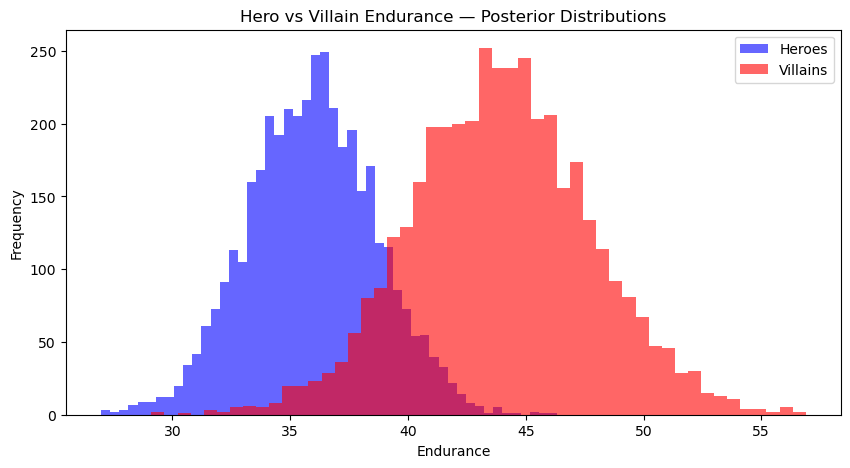

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Sample from the posterior distributions
hero_samples    = trace_endurance.posterior["hero_mu"].values.flatten()
villain_samples = trace_endurance.posterior["villain_mu"].values.flatten()

ax.hist(hero_samples,    bins=50, alpha=0.6, label="Heroes",   color="blue")
ax.hist(villain_samples, bins=50, alpha=0.6, label="Villains", color="red")

ax.set_xlabel("Endurance")
ax.set_ylabel("Frequency")
ax.set_title("Hero vs Villain Endurance — Posterior Distributions")
ax.legend()

plt.show()

In [7]:
hero_reason    = df_marvel[df_marvel["Alignment"] == "Hero"]["R"].values
villain_reason = df_marvel[df_marvel["Alignment"] == "Villain"]["R"].values

print("Heroes:  ", hero_reason)
print("Villains:", villain_reason)


Heroes:   [10  4 20 10 20 10  6  6  6 20 10  6 10 20  6 10  2 10 10 10 40 40 10 50
 20 10  6 10 40  6  6 30 20  6 20 20  6  6 10  6  6 10 20  6  6 10 10 10
  6 10 10 20 10 20  6 10 10 10 20  6 10 10 10]
Villains: [30 10 20 20 10 10 50 20  2 10 20 10  2 20 50  4 20  6 40  6 10 30 30  6
 10 40 30 30 40 20  6 10 10  6 30  6]


In [8]:
with pm.Model() as reason_model:
    
    # Hero reason
    hero_mu    = pm.Normal("hero_mu",    mu=13, sigma=10)
    hero_sigma = pm.HalfNormal("hero_sigma", sigma=15)
    
    # Villain reason  
    villain_mu    = pm.Normal("villain_mu",    mu=19, sigma=10)
    villain_sigma = pm.HalfNormal("villain_sigma", sigma=15)
    
    # Observed data
    hero_obs    = pm.Normal("hero_obs",    mu=hero_mu,    sigma=hero_sigma,    observed=hero_reason)
    villain_obs = pm.Normal("villain_obs", mu=villain_mu, sigma=villain_sigma, observed=villain_reason)
    
    trace_reason = pm.sample(1000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [hero_mu, hero_sigma, villain_mu, villain_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [9]:
az.summary(trace_reason, var_names=["hero_mu", "villain_mu", "hero_sigma", "villain_sigma"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hero_mu,12.944,1.183,10.807,15.201,0.015,0.019,6594.0,3335.0,1.0
villain_mu,18.695,2.237,14.701,23.141,0.030,0.033,5395.0,3346.0,1.0
hero_sigma,9.782,0.889,8.142,11.454,0.011,0.015,6134.0,2803.0,1.0
villain_sigma,13.965,1.711,10.787,17.027,0.024,0.028,5370.0,3222.0,1.0


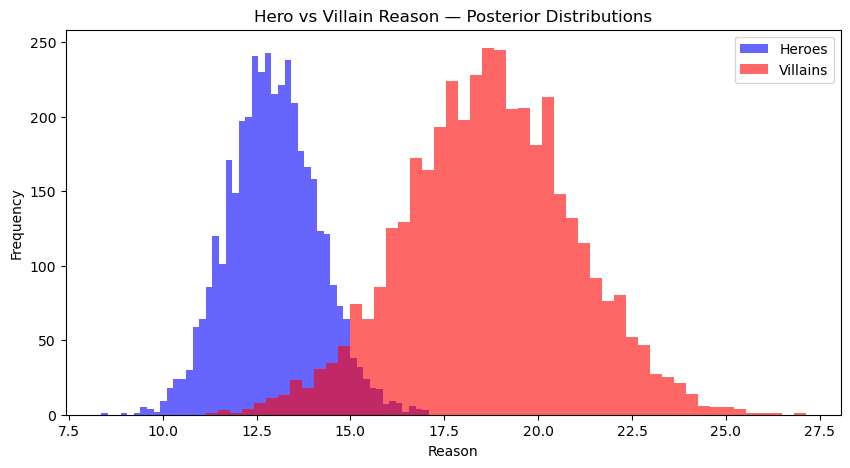

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

hero_samples    = trace_reason.posterior["hero_mu"].values.flatten()
villain_samples = trace_reason.posterior["villain_mu"].values.flatten()

ax.hist(hero_samples,    bins=50, alpha=0.6, label="Heroes",   color="blue")
ax.hist(villain_samples, bins=50, alpha=0.6, label="Villains", color="red")

ax.set_xlabel("Reason")
ax.set_ylabel("Frequency")
ax.set_title("Hero vs Villain Reason — Posterior Distributions")
ax.legend()

plt.show()

In [11]:
df_marvel["power_score"] = df_marvel[["F","A","S","E","R","I","P"]].mean(axis=1)

print(df_marvel[["character","power_score"]].sort_values("power_score", ascending=False).head(20))

         character  power_score
34   Silver surfer    65.714286
87        Firelord    62.142857
39            Thor    56.571429
15        Hercules    52.857143
45       Annihulus    39.285714
61            Loki    37.857143
37     Sub-Mariner    37.285714
51     Doctor Doom    37.142857
70          Ultron    36.285714
16            Hulk    36.142857
4              Box    35.714286
38           Thing    35.714286
50  Crimson Dynamo    33.571429
44      Wonder Man    33.285714
43       Wolverine    33.000000
20        Iron man    33.000000
35      Spider-man    32.857143
69    Titanium Man    32.142857
95             Fly    32.142857
21         Magneto    32.142857


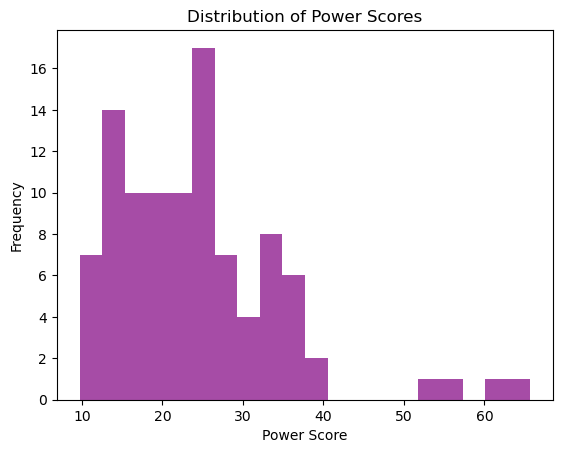

In [12]:

plt.hist(df_marvel["power_score"], bins=20, color="purple", alpha=0.7)
plt.xlabel("Power Score")
plt.ylabel("Frequency")
plt.title("Distribution of Power Scores")
plt.show()

In [13]:
power_scores = df_marvel["power_score"].values
print(power_scores)

[16.57142857 12.         25.71428571 13.14285714 35.71428571 28.57142857
 12.57142857 16.         25.28571429 22.28571429 15.14285714 28.71428571
 23.         21.42857143 13.14285714 52.85714286 36.14285714 12.28571429
 10.85714286 12.28571429 33.         32.14285714 19.42857143 20.28571429
 12.57142857 22.28571429 16.         26.42857143 30.71428571 20.85714286
 15.71428571 14.57142857 22.85714286 30.14285714 65.71428571 32.85714286
 20.28571429 37.28571429 35.71428571 56.57142857 26.57142857 19.42857143
 15.71428571 33.         33.28571429 39.28571429 19.71428571 18.
 16.28571429 15.14285714 33.57142857 37.14285714 16.         27.
 19.42857143 25.71428571 20.         21.28571429 29.42857143 25.14285714
 26.28571429 37.85714286 18.         21.42857143 12.57142857 23.42857143
 19.42857143 29.28571429 24.57142857 32.14285714 36.28571429 22.85714286
 28.57142857 24.28571429 20.         11.14285714 25.71428571 25.71428571
 26.57142857 15.14285714 25.14285714 14.         12.28571429 25.714

In [14]:
def assign_tier(score):
    if score >= 50:
        return "Cosmic"
    elif score >= 25:
        return "Powerhouse"
    else:
        return "Street Level"

df_marvel["tier"] = df_marvel["power_score"].apply(assign_tier)

print(df_marvel.groupby("tier")["power_score"].describe().round(1))
print("\n")
print(df_marvel[["character","power_score","tier"]].sort_values("power_score", ascending=False).head(20))

              count  mean  std   min   25%   50%   75%   max
tier                                                        
Cosmic          4.0  59.3  5.7  52.9  55.6  59.4  63.0  65.7
Powerhouse     40.0  30.2  4.3  25.1  26.2  29.4  33.1  39.3
Street Level   55.0  17.5  4.2   9.7  13.9  16.6  21.1  24.6


         character  power_score        tier
34   Silver surfer    65.714286      Cosmic
87        Firelord    62.142857      Cosmic
39            Thor    56.571429      Cosmic
15        Hercules    52.857143      Cosmic
45       Annihulus    39.285714  Powerhouse
61            Loki    37.857143  Powerhouse
37     Sub-Mariner    37.285714  Powerhouse
51     Doctor Doom    37.142857  Powerhouse
70          Ultron    36.285714  Powerhouse
16            Hulk    36.142857  Powerhouse
4              Box    35.714286  Powerhouse
38           Thing    35.714286  Powerhouse
50  Crimson Dynamo    33.571429  Powerhouse
44      Wonder Man    33.285714  Powerhouse
43       Wolverine    33.000000  

In [15]:
print(df_marvel["Type"].value_counts())


Type
Superhuman       32
Mutant           21
Technological    20
Human            14
Alien             4
Magical           3
God               3
Robot             2
Name: count, dtype: int64


In [16]:
main_types = ["Superhuman", "Mutant", "Technological", "Human"]
df_marvel["type_grouped"] = df_marvel["Type"].apply(lambda x: x if x in main_types else "Other")

print(df_marvel["type_grouped"].value_counts())

type_grouped
Superhuman       32
Mutant           21
Technological    20
Human            14
Other            12
Name: count, dtype: int64


In [17]:
print(df_marvel.groupby("type_grouped")["power_score"].describe().round(1))

               count  mean   std   min   25%   50%   75%   max
type_grouped                                                  
Human           14.0  19.3   6.8  11.1  13.3  17.6  25.4  29.3
Mutant          21.0  21.3   6.7  10.9  15.7  22.3  25.7  33.0
Other           12.0  35.5  14.7  19.7  23.1  31.6  42.7  62.1
Superhuman      32.0  25.5  10.4  12.3  19.1  25.7  30.5  65.7
Technological   20.0  22.4   8.2   9.7  16.2  20.7  27.3  37.1


In [18]:
from scipy.stats import f_oneway

groups = [df_marvel[df_marvel["type_grouped"] == t]["power_score"].values 
          for t in df_marvel["type_grouped"].unique()]

f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value:     {p_value:.4f}")

F-statistic: 5.968
P-value:     0.0003


In [19]:
from scipy.stats import tukey_hsd

groups_data = [df_marvel[df_marvel["type_grouped"] == t]["power_score"].values 
               for t in ["Human", "Mutant", "Technological", "Superhuman", "Other"]]

result = tukey_hsd(*groups_data)
print(result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -1.912     0.977   -11.041     7.218
 (0 - 2)     -3.046     0.889   -12.266     6.175
 (0 - 3)     -6.175     0.262   -14.654     2.303
 (0 - 4)    -16.141     0.000   -26.550    -5.732
 (1 - 0)      1.912     0.977    -7.218    11.041
 (1 - 2)     -1.134     0.995    -9.402     7.133
 (1 - 3)     -4.264     0.504   -11.695     3.167
 (1 - 4)    -14.230     0.001   -23.805    -4.654
 (2 - 0)      3.046     0.889    -6.175    12.266
 (2 - 1)      1.134     0.995    -7.133     9.402
 (2 - 3)     -3.129     0.777   -10.672     4.413
 (2 - 4)    -13.095     0.003   -22.757    -3.433
 (3 - 0)      6.175     0.262    -2.303    14.654
 (3 - 1)      4.264     0.504    -3.167    11.695
 (3 - 2)      3.129     0.777    -4.413    10.672
 (3 - 4)     -9.966     0.021   -18.923    -1.009
 (4 - 0)     16.141     0.000     5.732    26.550
 (4 - 1)     14.230     0.001     4.654    2

In [20]:
# First let's create numeric group indices
groups_list = ["Human", "Mutant", "Technological", "Superhuman", "Other"]
group_idx   = df_marvel["type_grouped"].map({g: i for i, g in enumerate(groups_list)}).values
obs_scores  = df_marvel["power_score"].values

print(group_idx)

[1 1 1 0 2 0 3 3 1 1 3 0 4 0 0 4 3 3 1 3 2 1 1 3 0 1 1 1 1 3 1 1 4 3 3 3 1
 3 3 4 3 2 3 1 3 4 4 2 2 0 2 2 2 4 3 2 0 3 3 3 3 4 3 2 2 1 3 0 2 2 4 2 3 0
 2 0 3 3 1 1 4 0 1 1 3 2 4 4 2 2 3 0 3 3 0 3 2 2 3]


In [21]:
with pm.Model() as anova_model:
    
    # A mean for each of the 5 groups
    group_mus   = pm.Normal("group_mus", mu=np.array([19, 21, 22, 25, 35]), sigma=10, shape=5)
    group_sigma = pm.HalfNormal("group_sigma", sigma=10)
    
    mu = group_mus[group_idx]
    
    obs = pm.Normal("obs", mu=mu, sigma=group_sigma, observed=obs_scores)
    
    trace_anova = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [group_mus, group_sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


In [22]:
az.summary(trace_anova, var_names=["group_mus"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
group_mus[0],19.324,2.494,14.808,24.152,0.023,0.027,11475.0,6484.0,1.0
group_mus[1],21.258,2.044,17.371,24.929,0.020,0.022,10568.0,6087.0,1.0
group_mus[2],22.379,2.098,18.540,26.437,0.019,0.022,11744.0,6935.0,1.0
group_mus[3],25.519,1.657,22.356,28.597,0.018,0.018,8948.0,6030.0,1.0
group_mus[4],35.468,2.659,30.530,40.536,0.028,0.029,9283.0,6261.0,1.0


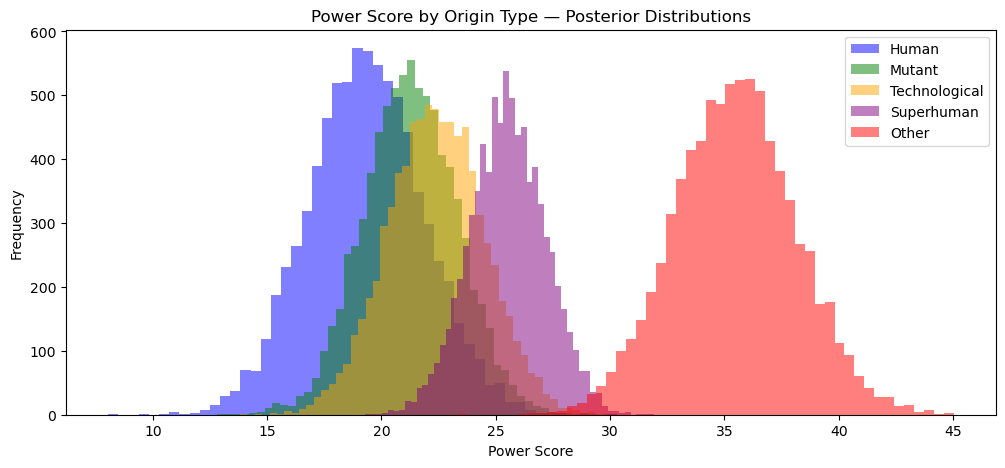

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ["blue", "green", "orange", "purple", "red"]

for i, (group, color) in enumerate(zip(groups_list, colors)):
    samples = trace_anova.posterior["group_mus"].values[:, :, i].flatten()
    ax.hist(samples, bins=50, alpha=0.5, label=group, color=color)

ax.set_xlabel("Power Score")
ax.set_ylabel("Frequency")
ax.set_title("Power Score by Origin Type — Posterior Distributions")
ax.legend()

plt.show()

In [24]:
features = ["F", "A", "S", "E", "R", "I", "P", "Flight", "Armour", "Ranged"]
target   = "type_grouped"

X = df_marvel[features]
y = df_marvel[target]

print(X.head())
print("\n")
print(y.value_counts())

    F   A   S   E   R   I   P  Flight  Armour  Ranged
0  20  30  10  30  10   6  10       6       0       0
1  20  20   6  20   4  10   4     150       0       0
2  40  40  30  20  20  10  20       0       0       0
3  30  20  10  10  10   6   6       0      10       0
4  30  30  75  75  20  10  10      40      50       0


type_grouped
Superhuman       32
Mutant           21
Technological    20
Human            14
Other            12
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        Human       1.00      1.00      1.00         1
       Mutant       0.50      0.40      0.44         5
        Other       0.00      0.00      0.00         1
   Superhuman       0.50      0.50      0.50         8
Technological       0.43      0.60      0.50         5

     accuracy                           0.50        20
    macro avg       0.49      0.50      0.49        20
 weighted avg       0.48      0.50      0.49        20



/opt/miniconda3/envs/math_lab/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/math_lab/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/math_lab/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [26]:
importances = pd.Series(rf.feature_importances_, index=features)
print(importances.sort_values(ascending=False))

P         0.149383
F         0.119334
S         0.115952
E         0.100776
Ranged    0.095457
R         0.092676
I         0.091011
Armour    0.084142
A         0.084016
Flight    0.067254
dtype: float64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, df_marvel["Alignment"], test_size=0.2, random_state=42)

rf_align = RandomForestClassifier(n_estimators=100, random_state=42)
rf_align.fit(X_train, y_train)

y_pred = rf_align.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Hero       0.79      0.79      0.79        14
     Villain       0.50      0.50      0.50         6

    accuracy                           0.70        20
   macro avg       0.64      0.64      0.64        20
weighted avg       0.70      0.70      0.70        20



In [28]:
importances_align = pd.Series(rf_align.feature_importances_, index=features)
print(importances_align.sort_values(ascending=False))

Ranged    0.186353
S         0.139539
F         0.113269
R         0.106615
E         0.102807
P         0.093126
A         0.086521
Flight    0.063977
Armour    0.062253
I         0.045540
dtype: float64


In [29]:
print(df_marvel.groupby("Alignment")["Ranged"].mean().round(1))

Alignment
Hero       12.4
Villain    28.2
Name: Ranged, dtype: float64


In [30]:
hero_ranged    = df_marvel[df_marvel["Alignment"] == "Hero"]["Ranged"].values
villain_ranged = df_marvel[df_marvel["Alignment"] == "Villain"]["Ranged"].values

print("Heroes:  ", hero_ranged)
print("Villains:", villain_ranged)

Heroes:   [  0   0   0   0   0   0  75   0   0  50  20   0  50  20  20   0   0 100
  30   0  75   0  40   0   0   0   0  50   0   0   0   0   0   0 100   0
   0   0   0   0   0  40  30   0   0   0  20   0   0  20   0   0   0   0
   0  20   0   0   0   0   0  20   0]
Villains: [100  50  20   0  40  40  50   0  40   0  30   4  40  10  40   0  75   0
  30  20   0   0   0  30  50  75   0 100  40   0   0   0  50  30  30  20]


In [31]:
with pm.Model() as ranged_model:
    
    hero_mu    = pm.Normal("hero_mu",    mu=12, sigma=10)
    hero_sigma = pm.HalfNormal("hero_sigma", sigma=15)
    
    villain_mu    = pm.Normal("villain_mu",    mu=28, sigma=10)
    villain_sigma = pm.HalfNormal("villain_sigma", sigma=15)
    
    hero_obs    = pm.Normal("hero_obs",    mu=hero_mu,    sigma=hero_sigma,    observed=hero_ranged)
    villain_obs = pm.Normal("villain_obs", mu=villain_mu, sigma=villain_sigma, observed=villain_ranged)
    
    trace_ranged = pm.sample(1000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [hero_mu, hero_sigma, villain_mu, villain_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [32]:
az.summary(trace_ranged, var_names=["hero_mu", "villain_mu", "hero_sigma", "villain_sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hero_mu,12.252,2.971,6.801,17.717,0.035,0.047,7028.0,3338.0,1.0
villain_mu,28.132,4.334,19.910,36.099,0.055,0.066,6213.0,3378.0,1.0
hero_sigma,24.330,2.102,20.494,28.341,0.027,0.033,6191.0,3232.0,1.0
villain_sigma,27.908,3.183,22.436,34.066,0.047,0.051,4908.0,3385.0,1.0


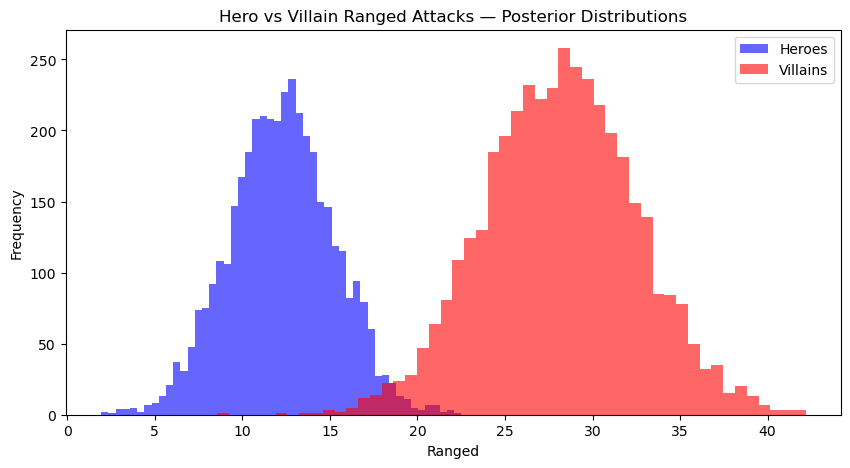

In [33]:
xfig, ax = plt.subplots(figsize=(10, 5))

hero_samples    = trace_ranged.posterior["hero_mu"].values.flatten()
villain_samples = trace_ranged.posterior["villain_mu"].values.flatten()

ax.hist(hero_samples,    bins=50, alpha=0.6, label="Heroes",   color="blue")
ax.hist(villain_samples, bins=50, alpha=0.6, label="Villains", color="red")

ax.set_xlabel("Ranged")
ax.set_ylabel("Frequency")
ax.set_title("Hero vs Villain Ranged Attacks — Posterior Distributions")
ax.legend()

plt.show()

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.20751925  0.30461647 -0.66411295 -0.38777206 -0.43825261 -0.8179084
  -0.58707757 -0.1953638  -0.27228295 -0.67807078]
 [-0.20751925 -0.29612119 -0.82168558 -0.82155097 -0.96098765 -0.57922621
  -0.90181049  0.0247853  -0.27228295 -0.67807078]
 [ 0.94991207  0.90535414  0.12375023 -0.82155097  0.43297246 -0.57922621
  -0.0625227  -0.20453668 -0.27228295 -0.67807078]
 [ 0.37119641 -0.29612119 -0.66411295 -1.25532989 -0.43825261 -0.8179084
  -0.79689951 -0.20453668 -0.17307054 -0.67807078]
 [ 0.37119641  0.30461647  1.89644236  1.56423306  0.43297246 -0.57922621
  -0.58707757 -0.14338415  0.2237791  -0.67807078]]


In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained: {pca.explained_variance_ratio_.round(3)}")

Variance explained: [0.265 0.154]


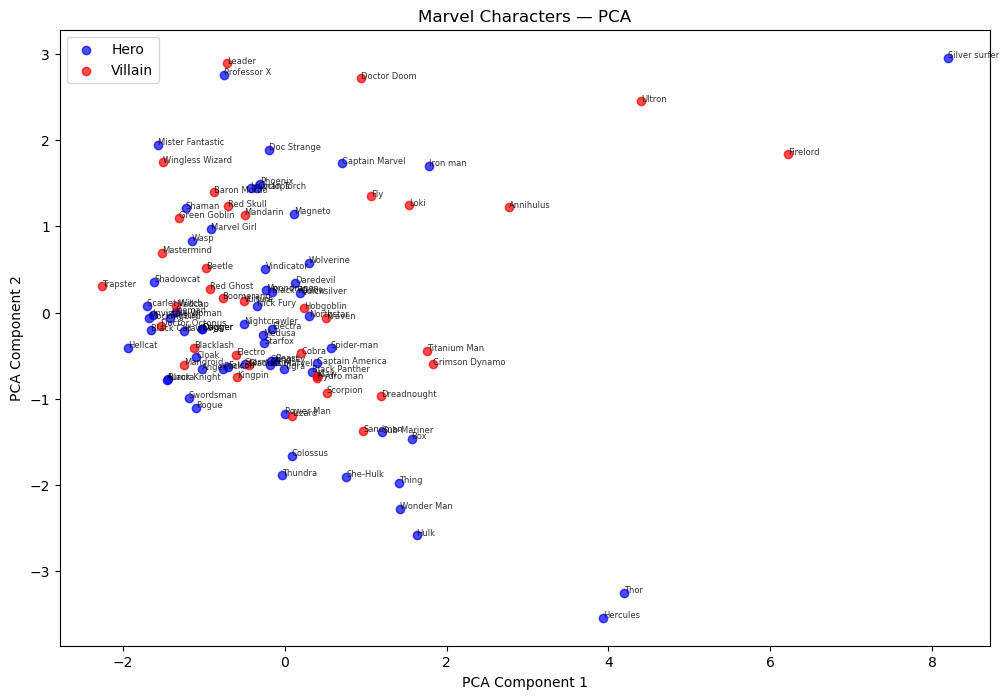

In [36]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = {"Hero": "blue", "Villain": "red"}

for alignment in ["Hero", "Villain"]:
    mask = df_marvel["Alignment"] == alignment
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[alignment], label=alignment, alpha=0.7)

for i, name in enumerate(df_marvel["character"]):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=6, alpha=0.8)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("Marvel Characters — PCA")
ax.legend()

plt.show()

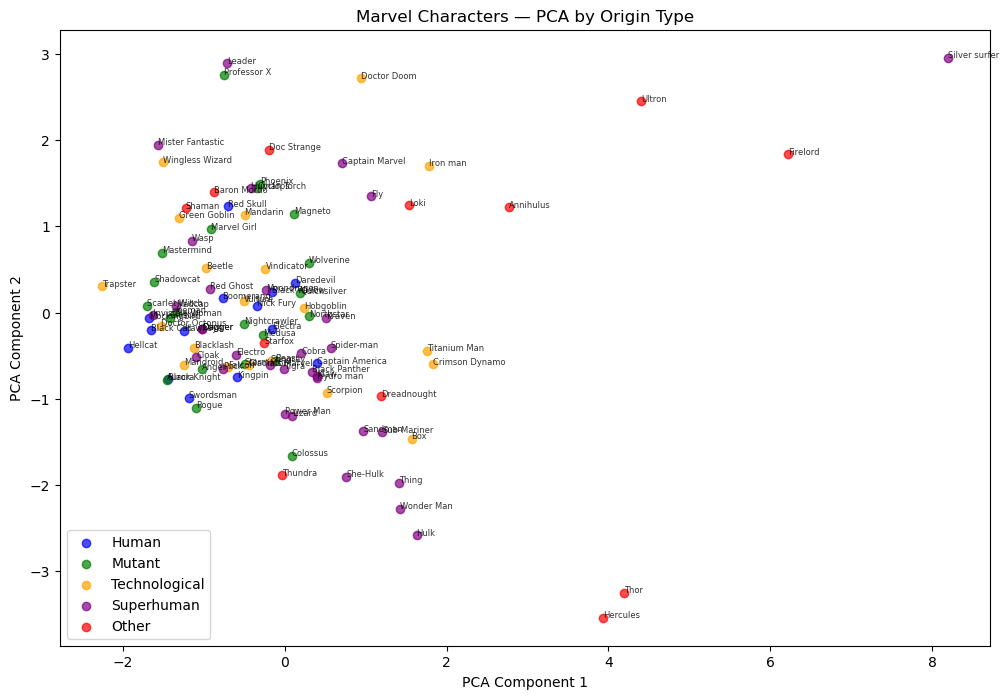

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))

color_map = {
    "Human":        "blue",
    "Mutant":       "green",
    "Technological":"orange",
    "Superhuman":   "purple",
    "Other":        "red"
}

for origin in color_map:
    mask = df_marvel["type_grouped"] == origin
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color_map[origin], label=origin, alpha=0.7)

for i, name in enumerate(df_marvel["character"]):
    ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=6, alpha=0.8)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("Marvel Characters — PCA by Origin Type")
ax.legend()

plt.show()

In [38]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

print("Done!")

/opt/miniconda3/envs/math_lab/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done!


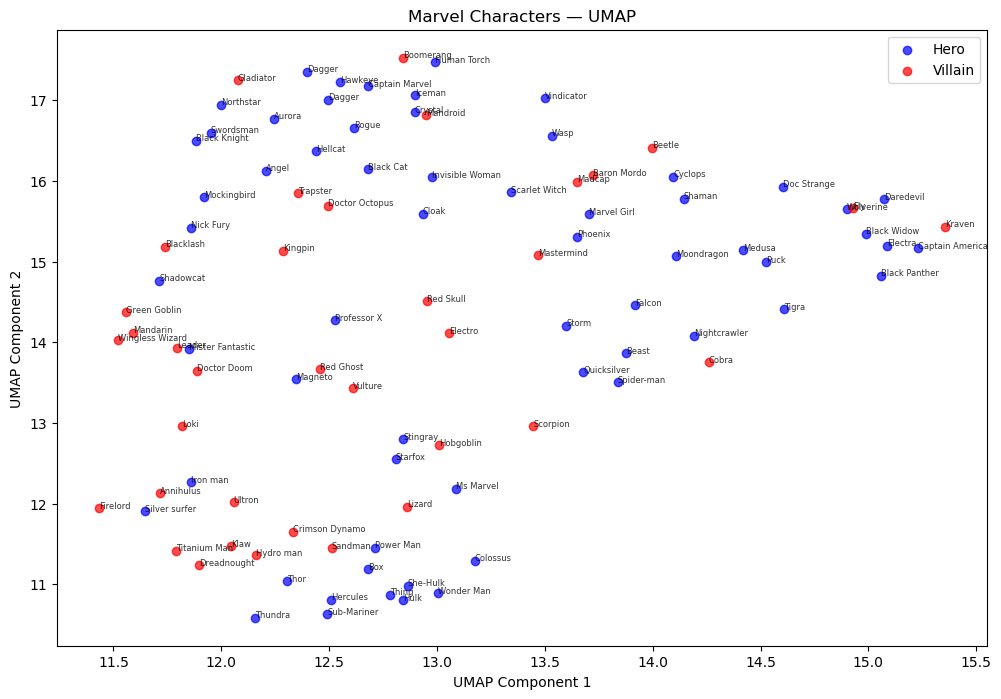

In [39]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = {"Hero": "blue", "Villain": "red"}

for alignment in ["Hero", "Villain"]:
    mask = df_marvel["Alignment"] == alignment
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=colors[alignment], label=alignment, alpha=0.7)

for i, name in enumerate(df_marvel["character"]):
    ax.annotate(name, (X_umap[i, 0], X_umap[i, 1]), fontsize=6, alpha=0.8)

ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_title("Marvel Characters — UMAP")
ax.legend()

plt.show()

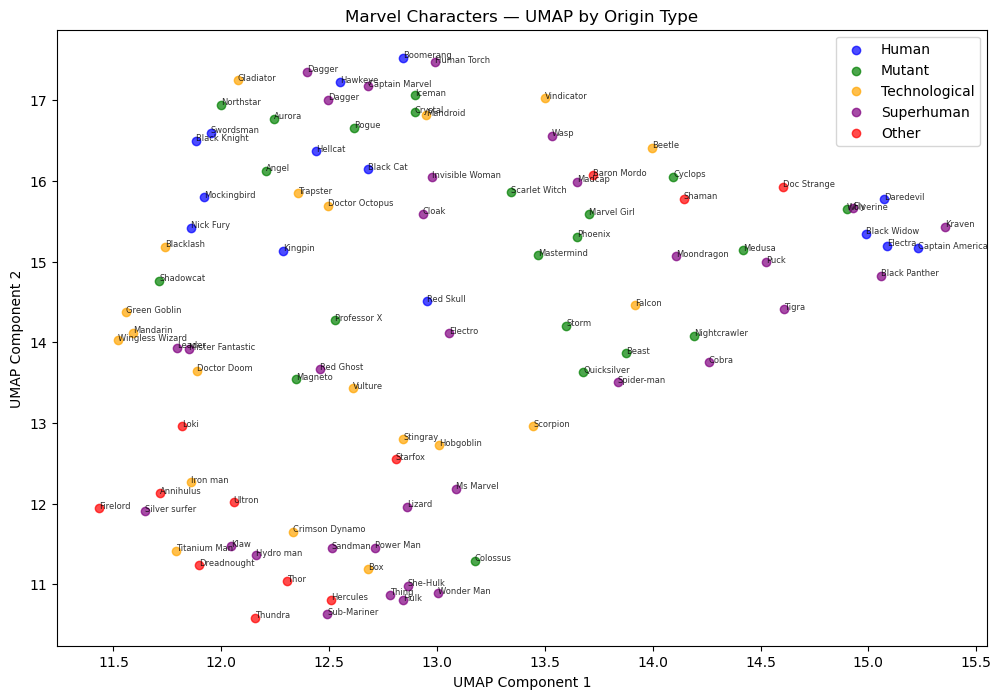

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))

for origin, color in color_map.items():
    mask = df_marvel["type_grouped"] == origin
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, label=origin, alpha=0.7)

for i, name in enumerate(df_marvel["character"]):
    ax.annotate(name, (X_umap[i, 0], X_umap[i, 1]), fontsize=6, alpha=0.8)

ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_title("Marvel Characters — UMAP by Origin Type")
ax.legend()

plt.show()